# 반도체 공정 스케줄링 시뮬레이션 결과

## 환경 설정

In [1]:
import os
import simpy
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Noto Sans KR'

# .env 파일의 환경 변수 로드
load_dotenv()

# .env 파일의 파라미터
BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data')

## 모듈 import

In [2]:
from utils import DataLoader, EventLogger
from utils.visualizer import create_gantt_chart
from simulation import Scheduler, Job
from simulation.planned_scheduler import PlannedScheduler as Scheduler
# 향후 알고리즘 모듈 추가 예정
# from algorithms.genetic import GeneticScheduler
# from algorithms.rule_based import RuleBasedScheduler
from algorithms.rule_based.stage1_gurobi import FJSPGurobiScheduler

## 데이터 로드

In [3]:
data_loader = DataLoader(BASE_DATA_PATH)

data = data_loader.load_all_data()

print("=" * 60)
print("데이터 개요")
print("=" * 60)
print(f"Jobs: {len(data['jobs'])} 개")
print(f"Operations: {len(data['operations'])} 개")
print(f"Machines: {len(data['machines'])} 개")
print(f"Machine Failures: {len(data['machine_failure'])} 개")
print(f"Setup Times: {len(data['setup_times'])} 개")
print(f"Operation-Machine Map: {len(data['operation_machine_map'])} 개")


qtime_constraints = pd.read_csv(os.path.join(BASE_DATA_PATH, "qtime_constraints.csv"))

optimizer = FJSPGurobiScheduler(
    jobs_df=data["jobs"],
    operations_df=data["operations"],
    machines_df=data["machines"],
    op_machine_df=data["operation_machine_map"],
    qtime_constraints_df=qtime_constraints,
    setup_times_df=data["setup_times"],
    qtime_weight=100.0,
    time_limit=300.0,
)

stage1_result = optimizer.solve()
stage1_result.to_csv("stage1_schedule_result.csv", index=False)
stage1_result

데이터 개요
Jobs: 10 개
Operations: 35 개
Machines: 8 개
Machine Failures: 8 개
Setup Times: 12 개
Operation-Machine Map: 95 개
Set parameter Username
Set parameter LicenseID to value 2773517
Academic license - for non-commercial use only - expires 2027-02-02
Set parameter TimeLimit to value 300
Set parameter LogToConsole to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.4.0 25E253)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 2865 rows, 1271 columns and 11265 nonzeros (Min)
Model fingerprint: 0x527bdb38
Model has 26 linear objective coefficients
Variable types: 96 continuous, 1175 integer (1175 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+03]
  Objective range  [1e+00, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 5e+03]

Presolve removed 620 rows and 571 columns
Presolve time: 0.02s
Presolved: 2245 rows, 700 c

,job_id,op_id,op_seq,machine_id,start_time,end_time
0,J1,J1_O1,1,M2,0.0,8.0
1,J1,J1_O2,2,M5,8.0,23.0
2,J1,J1_O3,3,M2,23.0,34.0
3,J1,J1_O4,4,M8,34.0,43.0
4,J10,J10_O1,1,M3,30.0,42.0
5,J10,J10_O2,2,M5,55.0,67.0
6,J10,J10_O3,3,M6,67.0,82.0
7,J2,J2_O1,1,M1,0.0,8.0
8,J2,J2_O2,2,M4,8.0,23.0
9,J2,J2_O3,3,M6,23.0,31.0


## 시뮬레이션 실행

In [4]:
# SimPy 환경 생성
env = simpy.Environment()

# 이벤트 로거 생성
event_logger = EventLogger(env)

# 스케줄러 생성
scheduler = Scheduler(
    env=env,
    machine_df=data["machines"],
    operations_df=data["operations"],
    machine_failure_df=data["machine_failure"],
    setup_times_df=data["setup_times"],
    op_machine_df=data["operation_machine_map"],
    planned_schedule_df=stage1_result,
    event_logger=event_logger,
    enable_failure=False,
)

scheduler.attach_job_types(data["jobs"])

## 작업 생성

In [6]:
jobs = []
for _, job_info in data['jobs'].iterrows():
    # 해당 작업의 operation 정보 가져오기
    job_operations = data['operations'].loc[
        data['operations']['job_id'] == job_info['job_id'],
        ['op_id', 'op_seq', 'qtime']
    ].sort_values('op_seq')
    
    # Job 인스턴스 생성
    job = Job(
        env=env,
        job_info=job_info.to_dict(),
        op_info=job_operations,
        scheduler=scheduler,
        event_logger=event_logger
    )
    jobs.append(job)

## 시뮬레이션 실행

In [7]:
env.run(until=env.all_of(job.process for job in jobs))
fig = create_gantt_chart(
    logs=event_logger.logs,
    max_time=env.now,
    title=f"반도체 공정 간트 차트 (Simulation Time: {round(env.now, 3)})")
fig.show()

In [8]:
import pandas as pd

def compare_gurobi_vs_simulation(stage1_result: pd.DataFrame, logs: list):
    """
    stage1_result : Gurobi 결과 DataFrame
        required columns:
        [job_id, op_id, op_seq, machine_id, start_time, end_time]

    logs : event_logger.logs
        EventLogger가 남긴 raw log list
    """

    # -----------------------------
    # 1) planned schedule 정리
    # -----------------------------
    planned = stage1_result.copy()
    planned = planned.sort_values(["job_id", "op_seq"]).reset_index(drop=True)
    planned["planned_duration"] = planned["end_time"] - planned["start_time"]

    # -----------------------------
    # 2) simulation logs -> DataFrame
    # -----------------------------
    df_logs = pd.DataFrame(logs).copy()

    if df_logs.empty:
        raise ValueError("event_logger.logs가 비어 있습니다.")

    # finish 없는 경우 대비
    if "finish" not in df_logs.columns:
        df_logs["finish"] = None

    # job resource의 working 이벤트만 추출
    # description 예시: "machine: M1\noperation: O11"
    job_work = df_logs[
        (df_logs["resource"] == "job") &
        (df_logs["event"] == "working")
    ].copy()

    if job_work.empty:
        raise ValueError("simulation log에서 job-working 이벤트를 찾지 못했습니다.")

    # -----------------------------
    # 3) description 파싱
    # -----------------------------
    def parse_description(desc):
        machine_id = None
        op_id = None

        if isinstance(desc, str):
            parts = desc.split("\n")
            for p in parts:
                p = p.strip()
                if p.startswith("machine:"):
                    machine_id = p.split(":", 1)[1].strip()
                elif p.startswith("operation:"):
                    op_id = p.split(":", 1)[1].strip()

        return pd.Series([machine_id, op_id])

    job_work[["actual_machine_id", "op_id"]] = job_work["description"].apply(parse_description)

    # job resource의 id == job_id 라고 가정
    job_work = job_work.rename(columns={
        "id": "job_id",
        "start": "actual_start_time",
        "finish": "actual_end_time"
    })

    # 필요한 컬럼만
    actual = job_work[[
        "job_id", "op_id", "actual_machine_id", "actual_start_time", "actual_end_time"
    ]].copy()

    # op_seq는 planned에서 붙이기
    actual = actual.merge(
        planned[["job_id", "op_id", "op_seq"]],
        on=["job_id", "op_id"],
        how="left"
    )

    actual = actual.sort_values(["job_id", "op_seq"]).reset_index(drop=True)

    # -----------------------------
    # 4) planned vs actual merge
    # -----------------------------
    compare_df = planned.merge(
        actual,
        on=["job_id", "op_id", "op_seq"],
        how="left"
    )

    # -----------------------------
    # 5) 차이 계산
    # -----------------------------
    compare_df["machine_match"] = compare_df["machine_id"] == compare_df["actual_machine_id"]
    compare_df["start_diff"] = compare_df["actual_start_time"] - compare_df["start_time"]
    compare_df["end_diff"] = compare_df["actual_end_time"] - compare_df["end_time"]

    # actual missing 여부
    compare_df["executed"] = compare_df["actual_start_time"].notna()

    # 보기 좋게 컬럼 정리
    compare_df = compare_df[[
        "job_id", "op_id", "op_seq",
        "machine_id", "actual_machine_id", "machine_match",
        "start_time", "actual_start_time", "start_diff",
        "end_time", "actual_end_time", "end_diff",
        "executed"
    ]]

    # -----------------------------
    # 6) makespan 비교
    # -----------------------------
    planned_makespan = planned["end_time"].max()
    actual_makespan = actual["actual_end_time"].max()

    makespan_summary = pd.DataFrame([{
        "planned_makespan": planned_makespan,
        "actual_makespan": actual_makespan,
        "difference": actual_makespan - planned_makespan
    }])

    # -----------------------------
    # 7) machine별 작업 순서 비교
    # -----------------------------
    planned_seq = (
        planned.sort_values(["machine_id", "start_time"])
        .groupby("machine_id")["op_id"]
        .apply(list)
        .reset_index(name="planned_op_sequence")
    )

    actual_seq = (
        actual.sort_values(["actual_machine_id", "actual_start_time"])
        .groupby("actual_machine_id")["op_id"]
        .apply(list)
        .reset_index(name="actual_op_sequence")
        .rename(columns={"actual_machine_id": "machine_id"})
    )

    machine_seq_compare = planned_seq.merge(actual_seq, on="machine_id", how="outer")
    machine_seq_compare["sequence_match"] = (
        machine_seq_compare["planned_op_sequence"] == machine_seq_compare["actual_op_sequence"]
    )

    return compare_df, makespan_summary, machine_seq_compare

compare_df, makespan_summary, machine_seq_compare = compare_gurobi_vs_simulation(
    stage1_result=stage1_result,
    logs=event_logger.logs
)

print("=== Makespan Comparison ===")
display(makespan_summary)

print("=== Operation-level Comparison ===")
display(compare_df)

print("=== Machine Sequence Comparison ===")
display(machine_seq_compare)


=== Makespan Comparison ===


,planned_makespan,actual_makespan,difference
0,104.0,112.0,8.0


=== Operation-level Comparison ===


,job_id,op_id,op_seq,machine_id,actual_machine_id,machine_match,start_time,actual_start_time,start_diff,end_time,actual_end_time,end_diff,executed
0,J1,J1_O1,1,M2,M2,True,0.0,0.0,0.0,8.0,8.0,0.0,True
1,J1,J1_O2,2,M5,M5,True,8.0,8.0,0.0,23.0,23.0,0.0,True
2,J1,J1_O3,3,M2,M2,True,23.0,23.0,0.0,34.0,34.0,0.0,True
3,J1,J1_O4,4,M8,M8,True,34.0,34.0,0.0,43.0,43.0,0.0,True
4,J10,J10_O1,1,M3,M3,True,30.0,34.0,4.0,42.0,46.0,4.0,True
5,J10,J10_O2,2,M5,M5,True,55.0,55.0,0.0,67.0,67.0,0.0,True
6,J10,J10_O3,3,M6,M6,True,67.0,69.0,2.0,82.0,84.0,2.0,True
7,J2,J2_O1,1,M1,M1,True,0.0,0.0,0.0,8.0,8.0,0.0,True
8,J2,J2_O2,2,M4,M4,True,8.0,8.0,0.0,23.0,23.0,0.0,True
9,J2,J2_O3,3,M6,M6,True,23.0,23.0,0.0,31.0,31.0,0.0,True


=== Machine Sequence Comparison ===


,machine_id,planned_op_sequence,actual_op_sequence,sequence_match
0,M1,"[J2_O1, J4_O1, J9_O1, J7_O1, J3_O3]","[J2_O1, J4_O1, J9_O1, J7_O1, J3_O3]",True
1,M2,"[J1_O1, J5_O1, J1_O3, J5_O3, J6_O1, J9_O3, J7_O3]","[J1_O1, J5_O1, J1_O3, J5_O3, J6_O1, J9_O3, J7_O3]",True
2,M3,"[J3_O1, J10_O1, J8_O1]","[J3_O1, J10_O1, J8_O1]",True
3,M4,"[J2_O2, J4_O2, J9_O2, J7_O2, J6_O2]","[J2_O2, J4_O2, J9_O2, J7_O2, J6_O2]",True
4,M5,"[J1_O2, J5_O2, J3_O2, J10_O2, J8_O2]","[J1_O2, J5_O2, J3_O2, J10_O2, J8_O2]",True
5,M6,"[J2_O3, J5_O4, J10_O3, J7_O4]","[J2_O3, J5_O4, J10_O3, J7_O4]",True
6,M7,"[J3_O4, J9_O4, J6_O3]","[J3_O4, J9_O4, J6_O3]",True
7,M8,"[J1_O4, J4_O3, J8_O3]","[J1_O4, J4_O3, J8_O3]",True


In [ ]:
import pandas as pd
import numpy as np

def compare_predecessor_vs_planned(stage1_result: pd.DataFrame, logs: list):
    """
    Gurobi planned schedule과 simulation actual log를 이용해
    각 operation에 대해:
      - planned start
      - actual predecessor completion
      - actual start
      - required start = max(planned start, actual predecessor completion)
      - extra delay = actual start - required start
    를 비교한다.

    Parameters
    ----------
    stage1_result : pd.DataFrame
        columns:
        [job_id, op_id, op_seq, machine_id, start_time, end_time]

    logs : list
        event_logger.logs

    Returns
    -------
    pd.DataFrame
    """

    # -----------------------------
    # 1) planned result 정리
    # -----------------------------
    planned = stage1_result.copy()
    planned = planned.sort_values(["job_id", "op_seq"]).reset_index(drop=True)

    # predecessor 정보 생성
    planned["pred_op_id"] = planned.groupby("job_id")["op_id"].shift(1)
    planned["pred_op_seq"] = planned.groupby("job_id")["op_seq"].shift(1)

    # -----------------------------
    # 2) simulation logs -> actual working info
    # -----------------------------
    df_logs = pd.DataFrame(logs).copy()

    if df_logs.empty:
        raise ValueError("event_logger.logs가 비어 있습니다.")

    job_work = df_logs[
        (df_logs["resource"] == "job") &
        (df_logs["event"] == "working")
    ].copy()

    if job_work.empty:
        raise ValueError("job working 로그를 찾지 못했습니다.")

    def parse_description(desc):
        machine_id = None
        op_id = None

        if isinstance(desc, str):
            for line in desc.split("\n"):
                line = line.strip()
                if line.startswith("machine:"):
                    machine_id = line.split(":", 1)[1].strip()
                elif line.startswith("operation:"):
                    op_id = line.split(":", 1)[1].strip()

        return pd.Series([machine_id, op_id])

    job_work[["actual_machine_id", "op_id"]] = job_work["description"].apply(parse_description)

    actual = job_work.rename(columns={
        "id": "job_id",
        "start": "actual_start_time",
        "finish": "actual_end_time"
    })[["job_id", "op_id", "actual_machine_id", "actual_start_time", "actual_end_time"]].copy()

    # planned에서 op_seq 붙이기
    actual = actual.merge(
        planned[["job_id", "op_id", "op_seq"]],
        on=["job_id", "op_id"],
        how="left"
    )

    actual = actual.sort_values(["job_id", "op_seq"]).reset_index(drop=True)

    # -----------------------------
    # 3) planned + actual merge
    # -----------------------------
    compare_df = planned.merge(
        actual,
        on=["job_id", "op_id", "op_seq"],
        how="left"
    )

    # predecessor의 actual_end_time 붙이기
    pred_actual = actual[["job_id", "op_id", "actual_end_time"]].rename(columns={
        "op_id": "pred_op_id",
        "actual_end_time": "actual_pred_end_time"
    })

    compare_df = compare_df.merge(
        pred_actual,
        on=["job_id", "pred_op_id"],
        how="left"
    )

    # 첫 공정은 predecessor 없음
    compare_df["actual_pred_end_time"] = compare_df["actual_pred_end_time"].fillna(-np.inf)

    # required start = max(planned start, actual predecessor completion)
    compare_df["required_start_time"] = compare_df[["start_time", "actual_pred_end_time"]].max(axis=1)

    # extra delay = actual start - required start
    compare_df["extra_delay_after_pred"] = compare_df["actual_start_time"] - compare_df["required_start_time"]

    # planned vs predecessor 영향 분해
    compare_df["pred_delay_component"] = compare_df["required_start_time"] - compare_df["start_time"]
    compare_df["total_start_diff"] = compare_df["actual_start_time"] - compare_df["start_time"]

    # 보기 좋게
    compare_df["pred_delay_component"] = compare_df["pred_delay_component"].replace(-np.inf, 0.0)

    # 첫 operation 처리용
    compare_df.loc[compare_df["pred_op_id"].isna(), "actual_pred_end_time"] = np.nan
    compare_df.loc[compare_df["pred_op_id"].isna(), "pred_delay_component"] = 0.0

    result_cols = [
        "job_id", "op_id", "op_seq",
        "pred_op_id",
        "start_time",                 # planned processing start
        "actual_pred_end_time",       # actual predecessor completion
        "required_start_time",        # max(planned start, actual pred end)
        "actual_start_time",
        "pred_delay_component",       # predecessor 때문에 최소한 밀려야 했던 시간
        "extra_delay_after_pred",     # predecessor 외 추가 지연
        "total_start_diff",
        "actual_end_time",
    ]

    return compare_df[result_cols].sort_values(["job_id", "op_seq"]).reset_index(drop=True)
pred_compare_df = compare_predecessor_vs_planned(
    stage1_result=stage1_result,
    logs=event_logger.logs
)

display(pred_compare_df)

## 시뮬레이션 KPI 및 통계

### 작업별 통계

In [9]:
df_logs = pd.DataFrame(event_logger.logs)
completed_cnt = 0
completed_in_due_date = 0
total_qtime_violation = 0.0
for job in jobs:
    print(f"Job ID: {job.id}, QTime Violation: {round(job.calculate_qtime_over(env.now), 3)}")
    completed_cnt += int(job.is_completed)
    completed_in_due_date = int(job.is_in_due_date())
    total_qtime_violation += job.total_qtime_over
print(f"총 작업 수: {len(jobs)}\n완료된 작업 수: {completed_cnt}\n기한 안에 완료된 작업 수: {completed_in_due_date}\n총 QTime 위반 시간: {round(total_qtime_violation, 3)}")
# 향후 결과 분석 기능 추가
# - 평균 대기 시간
# - 장비 가동률

Job ID: J1, QTime Violation: 0.0
Job ID: J2, QTime Violation: 0.0
Job ID: J3, QTime Violation: 0.0
Job ID: J4, QTime Violation: 0.0
Job ID: J5, QTime Violation: 0.0
Job ID: J6, QTime Violation: 10.0
Job ID: J7, QTime Violation: 0.0
Job ID: J8, QTime Violation: 0.0
Job ID: J9, QTime Violation: 0.0
Job ID: J10, QTime Violation: 0.0
총 작업 수: 10
완료된 작업 수: 10
기한 안에 완료된 작업 수: 0
총 QTime 위반 시간: 10.0


,waiting,setup,working,job_type
id,,,,
J1,0.0,0.0,43.0,P1
J3,19.0,0.0,55.0,P1
J5,4.0,3.0,47.0,P1
J7,30.0,3.0,53.0,P1
J9,0.0,17.0,51.0,P1
J10,4.0,11.0,39.0,P2
J2,0.0,0.0,31.0,P2
J4,16.0,2.0,43.0,P2
J6,49.0,11.0,37.0,P2


findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
/Users/miles/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/miles/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
/Users/miles/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:17

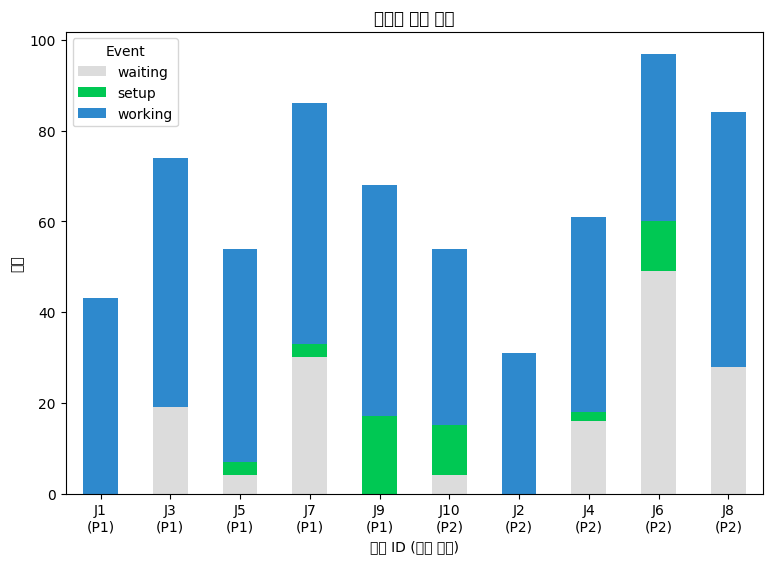

In [10]:
job_info = df_logs[df_logs['resource'] == 'job']
job_info['duration'] = round(job_info['finish'] - job_info['start'], 3)
job_info = job_info.groupby(['id', 'event'])['duration'].sum().reset_index(['id', 'event'], drop=False)
job_stacked = job_info.pivot(index='id', columns='event', values='duration').fillna(0)
job_stacked = job_stacked.reindex(columns=['waiting', 'setup', 'working'], fill_value=0)
job_type_map = data['jobs'].set_index('job_id')['job_type']
job_stacked = job_stacked.join(job_type_map).sort_values('job_type')
display(job_stacked)
job_stacked.index = [f"{i}\n({t})" for i, t in zip(job_stacked.index, job_stacked['job_type'])]
job_stacked.plot(kind='bar', stacked=True, figsize=(9, 6), color={
    "waiting": '#DCDCDC',
    "setup": '#00C853',
    "working": '#2E89CD'
})
plt.title("작업별 소요 시간")
plt.xlabel("작업 ID (작업 유형)")
plt.ylabel("시간")
plt.xticks(rotation=0)
plt.legend(title="Event")
plt.show()

### 공정별 설비 활용률

,utilization,group
id,,
M1,0.491071,G1
M2,0.633929,G1
M3,0.437500,G1
M4,0.651786,G2
M5,0.625000,G2
M6,0.446429,G3
M7,0.366071,G3
M8,0.410714,G3


/var/folders/fb/s0q1ctcn3j9g58_h29cms2vc0000gn/T/ipykernel_61667/3043275448.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=machine_utilization, x='group', y='utilization',
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
/Users/miles/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  fig.canva

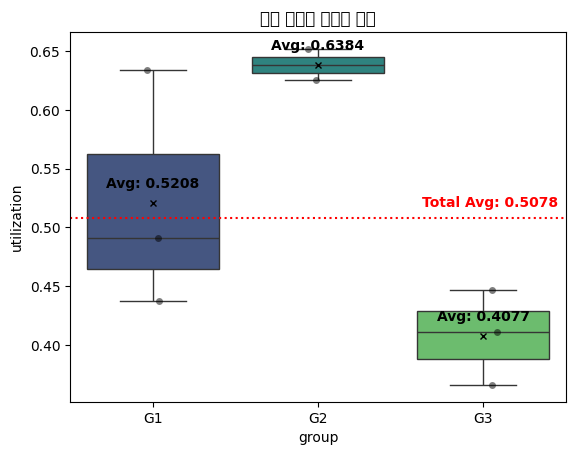

In [11]:
machine_info = df_logs[df_logs['resource'] == 'machine']
machine_info['utilization'] = machine_info['finish'] - machine_info['start']
machine_utilization = pd.DataFrame(machine_info[machine_info['event'] == 'working'].groupby('id')['utilization'].sum() / env.now)
machine_utilization['group'] = data['machines'].set_index('machine_id').loc[machine_utilization.index]['machine_group']
display(machine_utilization)
group_means = machine_utilization.groupby('group')['utilization'].mean()
total_mean = machine_utilization['utilization'].mean()
sns.boxplot(data=machine_utilization, x='group', y='utilization', 
            palette='viridis', showmeans=True,
            meanprops={"marker":"x", "markeredgecolor":"black", "markersize":"5"})
sns.stripplot(data=machine_utilization, x='group', y='utilization', 
              color='black', alpha=0.5, jitter=True)
for i, group in enumerate(group_means.index):
    mean_val = group_means[group]
    plt.text(i, mean_val + 0.01, f'Avg: {mean_val:.4f}', 
             ha='center', va='bottom', color='black', fontweight='bold')
plt.text(len(group_means)-0.55, total_mean + 0.01, f'Total Avg: {total_mean:.4f}', color='red', fontweight='bold', ha='right')
plt.axhline(total_mean, color='red', linestyle=':')
plt.title("공정 그룹별 가동률 분포")
plt.show()